# High-order SCAO performance

**Scientific question.** Increasing the deformable-mirror actuator count lowers
the fitting-error floor a closed loop can reach. Driving the *shared*
`shwfs_ao.control.run_closed_loop` engine at several actuator orders, how do the
steady-state residual wavefront error and the resulting near-infrared Maréchal
Strehl ratio improve with order?

This study and `detector_level_2m.ipynb` call the same loop engine; only the
scale differs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 1.5
WFS_WAVELENGTH_M = 700e-9
SCIENCE_WAVELENGTH_M = 1.65e-6
ORDERS = (5, 7) if FAST_SMOKE else (5, 7, 9)
N_STEPS = 6 if FAST_SMOKE else 14

## Configuration

In [4]:
def build_system(n_across):
    lenslets = n_across + 1
    pixels = 12 * lenslets
    geometry = build_shack_hartmann_geometry(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        pupil_shape=(pixels, pixels),
        n_lenslets_across=lenslets,
        min_fill_fraction=0.4,
    )
    optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
    sensor = build_detector_shack_hartmann_sensor(
        geometry,
        optics,
        DetectorConfig(photons_per_subap_frame=5e4),
        wfs_wavelength_m=WFS_WAVELENGTH_M,
        random_streams=NamedRandomStreams(SEED),
    )
    mirror = build_native_deformable_mirror(
        geometry.x_m,
        geometry.y_m,
        geometry.pupil_mask,
        DMConfig(
            telescope_diameter_m=TELESCOPE_DIAMETER_M,
            n_actuators_across=n_across,
            coupling_width_pitch=0.35,
            stroke_limit_nm=20000.0,
        ),
    )
    interaction = calibrate_interaction_matrix(
        DmActuatorProbeBasis(mirror),
        sensor,
        amplitude_m=25e-9,
        random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
        include_noise=False,
    )
    atmosphere = FrozenFlowAtmosphere(
        FrozenFlowAtmosphereConfig(
            grid_size=geometry.pupil_shape[0],
            delta_m=geometry.pupil_geometry.pixel_spacing_xy_m[0],
            pupil_diameter_m=TELESCOPE_DIAMETER_M,
            r0_m=0.25,
            outer_scale_m=25.0,
            wind_m_per_s=(8.0, 0.0),
            root_seed=SEED,
        ),
        pupil_mask=geometry.pupil_mask,
    )
    return sensor, mirror, interaction, atmosphere

## Simulation call

In [5]:
def run_order(n_across):
    sensor, mirror, interaction, atmosphere = build_system(n_across)
    history = run_closed_loop(
        LoopConfig(
            n_steps=N_STEPS,
            gain=0.5,
            leak=0.0,
            latency_frames=1,
            frame_rate_hz=1000.0,
            root_seed=SEED,
        ),
        random_streams=NamedRandomStreams(SEED),
        atmosphere=atmosphere,
        wfs=sensor,
        dm=mirror,
        interaction_matrix=interaction,
        reconstructor=LeastSquaresReconstructor(
            interaction, min_valid_fraction=0.5, min_rank=1
        ),
        command_projector=IdentityCommandProjector(mirror.actuator_ids),
        controller=LeakyIntegratorController(
            mirror.actuator_ids, gain=0.5, leak=0.0, latency_frames=1
        ),
        include_noise=False,
        realization_index=0,
    )
    residual = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
    settled = float(np.mean(residual[N_STEPS // 2:]))
    open_loop = float(np.mean(history.open_loop_opd_rms_m))
    # Maréchal approximation: Strehl ~ exp(-(2 pi sigma / lambda)^2).
    strehl = float(np.exp(-((2 * np.pi * settled / SCIENCE_WAVELENGTH_M) ** 2)))
    return settled, open_loop, strehl, int(mirror.n_actuators)

records = {order: run_order(order) for order in ORDERS}

## Diagnostic table

In [6]:
table = pd.DataFrame(
    [
        (
            order,
            records[order][3],
            records[order][1] * 1e9,
            records[order][0] * 1e9,
            records[order][2],
        )
        for order in ORDERS
    ],
    columns=[
        "actuators across",
        "active actuators",
        "open-loop RMS (nm)",
        "closed-loop RMS (nm)",
        "H-band Maréchal Strehl",
    ],
)
table

,actuators across,active actuators,open-loop RMS (nm),closed-loop RMS (nm),H-band Maréchal Strehl
0,5,13,363.869290,250.345266,0.403006
1,7,29,358.320293,230.781000,0.461945
2,9,49,366.948495,175.637761,0.639333


## Plot

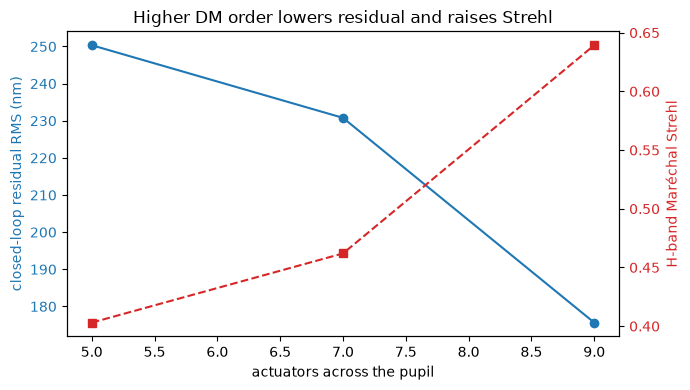

In [7]:
orders = list(ORDERS)
residual_nm = [records[o][0] * 1e9 for o in ORDERS]
strehl = [records[o][2] for o in ORDERS]
figure, left = plt.subplots(figsize=(7.0, 4.0))
left.plot(orders, residual_nm, "o-", color="C0", label="closed-loop RMS")
left.set_xlabel("actuators across the pupil")
left.set_ylabel("closed-loop residual RMS (nm)", color="C0")
left.tick_params(axis="y", labelcolor="C0")
right = left.twinx()
right.plot(orders, strehl, "s--", color="C3", label="H-band Strehl")
right.set_ylabel("H-band Maréchal Strehl", color="C3")
right.tick_params(axis="y", labelcolor="C3")
left.set_title("Higher DM order lowers residual and raises Strehl")
figure.tight_layout()
plt.show()

## Interpretation

As the actuator count rises, the loop resolves finer wavefront structure, the
steady-state residual RMS falls, and the near-infrared Strehl climbs
accordingly. The gain per added actuator shrinks — the fitting error follows a
power law in actuator pitch — so there are diminishing returns once the DM
out-resolves the sensed turbulence. This is the same convergence seen in
`mode_order_sampling.ipynb`, now produced by a real sensed-and-reconstructed
closed loop rather than an ideal modal projection.

## Limitations

- The Strehl is the Maréchal approximation from the residual RMS, valid for
  small residual phase; a full estimate would propagate the residual field.
- One atmospheric realization and a short run; production figures average over
  seeds and longer sequences.
- WFS measurement noise is disabled here to isolate fitting error; the noise
  budget is studied in `noise_latency_gain.ipynb`.
- The order scan stops where the DM is still well constrained by the sensor;
  pushing the actuator count past the sensed-mode count degrades the least-
  squares reconstruction conditioning rather than improving the residual.